## LABORATORIO — Observatorio de Datos (Pingüinos)

Objetivo
Guiar para la exploración, descripción, formulación de hipótesis y pruebas básicas usando el dataset de pingüinos, hasta generar un reporte reproducible. El laboratorio se divide en dos fases: (1) enfoque clásico con notebook y (2) enfoque con agentes.

Requisitos
- Python 3.x
- pandas, numpy, matplotlib, seaborn (opcional)
- scipy (opcional, para pruebas)

FASE 1 — Enfoque clásico (hasta Parte F)

Nota: el estudiante debe construir su propio runner (script en Python) para ejecutar operaciones y guardar artifacts.

Parte A — Observación inicial
1) ¿Cuántas filas y columnas tiene el dataset?
2) ¿Qué variables son numéricas y cuáles categóricas?
3) ¿Cuántos valores faltantes hay por columna?
4) ¿Existen filas duplicadas?
5) ¿Qué variables tienen baja cardinalidad?

Parte B — Descripción
6) Para cada variable numérica, reporte media, mediana, desviación estándar y rango intercuartílico.
7) Para cada variable categórica, reporte conteos y porcentajes.
8) Construya tablas cruzadas para pares de variables categóricas relevantes.
9) Calcule matrices de correlación (Pearson y Spearman) entre variables numéricas.

Parte C — Visualización
10) Genere gráficos de conteo para todas las variables categóricas de baja cardinalidad.
11) Genere histogramas para variables numéricas y describa su forma.
12) Genere boxplots de una variable numérica por categoría (p. ej., `bill_length_mm` por `species`).
13) Genere un scatter entre dos variables numéricas y coloree por una categoría.
14) Genere un heatmap de correlación.

Parte D — Hipótesis (sin causalidad)
15) Proponga al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.
   Ejemplos:
   - `flipper_length_mm` se asocia con `body_mass_g`.
   - `bill_length_mm` difiere por `species`.
   - `species` se asocia con `island`.

Parte E — Pruebas estadísticas
16) Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).
17) Reporte estadístico y p-valor.
18) Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

Parte F — Conclusiones y reporte
19) Redacte conclusiones en tres capas:
    A) Hallazgos descriptivos (con evidencia).
    B) Patrones visuales (con evidencia).
    C) Próximas hipótesis a probar.
20) Incluya preguntas para un investigador humano (p. ej., manejo de la variable `sex`, control por `species`).

Parte G — Ejecución del pipeline (opcional)
21) Ejecute el flujo automático:
    - python pipeline.py
22) Revise el HTML final en artifacts/observatorio.html.


FASE 2 — Enfoque con Agentes (Generalización)

En esta fase se introduce una arquitectura basada en la separación entre Agente y Runner. La idea central es simple: el agente planifica e interpreta, el runner ejecuta y calcula. El agente propone qué operaciones realizar y redacta conclusiones, pero no hace cálculos. El runner ejecuta código en Python, calcula estadísticas, genera gráficos y escribe artifacts (archivos JSON/PNG).

Esta separación mejora la reproducibilidad y reduce errores conceptuales: el agente solo puede usar la evidencia contenida en artifacts. No puede inventar valores ni asumir resultados.

El estudiante debe construir su propio runner y conectarlo con las recomendaciones del agente.

---

Preparación del agente

Primero se crea una carpeta independiente para este enfoque. Allí se copia el archivo de guía del agente (por ejemplo, Promts/hola_agentes.txt) y se adapta si es necesario. En cada interacción debe definirse claramente la fase actual (OBSERVE, DESCRIBE o HYPOTHESIZE_AND_CONCLUDE) y qué artifacts están disponibles.

---

Algoritmo general del enfoque con agentes

Antes de usar el agente, se debe tener claro qué es cada componente:

* Runner: script en Python que calcula, genera gráficos y escribe artifacts.
* Artifacts: archivos JSON o PNG que contienen resultados verificables. Son la única fuente válida de evidencia.
* Agente: propone acciones y redacta hipótesis o conclusiones con base en artifacts.

El proceso comienza preparando el runner. Se crea un archivo runner.py con funciones básicas de observación: perfil del dataset, inferencia de esquema, reporte de faltantes y duplicados. Se agrega la carga del dataset (por ejemplo, seaborn o CSV remoto) y la creación automática de la carpeta artifacts. El runner debe poder ejecutar la fase OBSERVE y generar artifacts/00_raw_profile.json.

Luego se inicia la interacción con el agente. En la fase OBSERVE se le indica que no hay artifacts disponibles. El agente responde con un plan de acciones de observación. El runner ejecuta esas acciones y escribe el artifact correspondiente.

Después se amplía el runner con funciones descriptivas: resúmenes numéricos y categóricos, tablas cruzadas, correlaciones y gráficos exploratorios. Se verifica que pueda generar artifacts/04_descriptive_stats.json y artifacts/05_visual_registry.json.

En la fase DESCRIBE, se informa al agente que ya existe el perfil del dataset. El agente propone análisis descriptivos y gráficos exploratorios. El runner ejecuta y guarda los nuevos artifacts.

En la fase HYPOTHESIZE_AND_CONCLUDE, el agente recibe como contexto los artifacts descriptivos. Con base en ellos formula hipótesis falsables, conclusiones descriptivas y preguntas para el humano. Estas se guardan en artifacts/06_hypotheses_log.json, artifacts/07_conclusions.json y, si aplica, artifacts/09_questions.json.

Opcionalmente, pueden ejecutarse pruebas estadísticas adicionales y registrar los resultados en artifacts/08_tests.json.

---

Interacción con el agente

El flujo es cíclico:

1. Solicitar al agente un plan acorde con la fase actual.
2. Ejecutar las acciones con el runner.
3. Guardar artifacts.
4. Repetir el ciclo en la siguiente fase.

En DESCRIBE, los gráficos deben seleccionarse de forma exploratoria, sin sesgo predefinido. En HYPOTHESIZE_AND_CONCLUDE, todas las afirmaciones deben estar sustentadas en artifacts.

---

Generalización

Una vez completado el flujo con un dataset inicial, se repite el proceso con un dataset distinto. El objetivo es verificar que la arquitectura funciona de forma general y analizar qué partes del prompt necesitan ajustes para adaptarse a otros contextos.

---

Entregables

* Reporte final en HTML.
* Resumen en Markdown.
* Hipótesis y conclusiones documentadas.
* Registro de interacción con el agente (prompts y decisiones).
* Comparación entre el enfoque clásico y el enfoque con agentes.

---

Criterios de evaluación

Se evalúa el rigor descriptivo (sin invención de valores), la coherencia entre gráficos e hipótesis, la claridad de las conclusiones, la reproducibilidad del flujo y la calidad de la interacción con el agente. También se considera la capacidad de generalizar el sistema a nuevos datasets.

Este enfoque no busca automatizar el pensamiento, sino estructurarlo: observar, describir e interpretar con evidencia verificable.


In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

## PART A

In [ ]:
#cargar los datos de los pingüinos desde seaborn e info de filas y columnas
penguins = sns.load_dataset("penguins")
penguins.to_csv("penguins.csv", index=False)  # respaldo local si lo necesitas
print(f"Dataset listo con {penguins.shape[0]} filas y {penguins.shape[1]} columnas.")

Dataset listo con 344 filas y 7 columnas.


In [4]:
#save the dataset as csv in the current directory
penguins = sns.load_dataset("penguins")
penguins.to_csv("penguins.csv", index=False)
print("Archivo guardado como penguins.csv")

Archivo guardado como penguins.csv


In [ ]:
#columnas numericas y categóricas del df
numeric_cols = penguins.select_dtypes(include="number").columns.tolist()
categorical_cols = penguins.select_dtypes(exclude="number").columns.tolist()
print("Numéricas:", numeric_cols)
print("Categóricas:", categorical_cols)

Numéricas: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
Categóricas: ['species', 'island', 'sex']


In [ ]:
#missing values 
penguins.isna().sum().to_frame("faltantes")

,faltantes
species,0
island,0
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2
sex,11


In [33]:
#Duplicated rows
dup_mask = penguins.duplicated()
print("Total duplicadas:", dup_mask.sum())
penguins[dup_mask]

Total duplicadas: 0


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex


In [ ]:
#cardinalidad de columnas categóricas
cardinality = penguins.nunique()
low_cardinality = cardinality[cardinality <= 5]  # ajusta el umbral si lo necesitas
display(low_cardinality.to_frame("cardinalidad"))

,cardinalidad
species,3
island,3
sex,2


In [35]:
# hacemos una pequeña limpieza de datos para quitar esas fials que están mayormente vacías
min_non_null = penguins.shape[1] // 2 + 1 
penguins_clean = penguins.dropna(thresh=min_non_null)

print(f"Filas originales: {len(penguins)}")
print(f"Filas después de limpiar: {len(penguins_clean)}")

Filas originales: 344
Filas después de limpiar: 342


## PART B

In [ ]:
#estadísitaca de cols numéricas
numeric_cols = penguins_clean.select_dtypes(include="number")

stats = pd.DataFrame({
    "media": numeric_cols.mean(),
    "mediana": numeric_cols.median(),
    "desviacion_std": numeric_cols.std(ddof=1),
    "rango_intercuartil": numeric_cols.quantile(0.75) - numeric_cols.quantile(0.25),
})

display(stats)

,media,mediana,desviacion_std,rango_intercuartil
bill_length_mm,43.921930,44.45,5.459584,9.275
bill_depth_mm,17.151170,17.30,1.974793,3.100
flipper_length_mm,200.915205,197.00,14.061714,23.000
body_mass_g,4201.754386,4050.00,801.954536,1200.000


In [37]:
#stats for categorical columns
categorical_cols = penguins_clean.select_dtypes(exclude="number").columns

summary = {}
for col in categorical_cols:
    counts = penguins_clean[col].value_counts(dropna=False)
    percents = (counts / len(penguins_clean)) * 100
    summary[col] = pd.DataFrame({"conteos": counts, "porcentaje": percents.round(2)})

for col, table in summary.items():
    print(f"\n=== {col} ===")
    display(table)


=== species ===


,conteos,porcentaje
species,,
Adelie,151,44.15
Gentoo,123,35.96
Chinstrap,68,19.88



=== island ===


,conteos,porcentaje
island,,
Biscoe,167,48.83
Dream,124,36.26
Torgersen,51,14.91



=== sex ===


,conteos,porcentaje
sex,,
Male,168,49.12
Female,165,48.25
NaN,9,2.63


In [38]:
#cross-tabulations
ct_species_island = pd.crosstab(penguins_clean["species"], penguins_clean["island"], margins=True)
ct_species_sex = pd.crosstab(penguins_clean["species"], penguins_clean["sex"], margins=True)
ct_island_sex = pd.crosstab(penguins_clean["island"], penguins_clean["sex"], margins=True)

display(ct_species_island)
display(ct_species_sex)
display(ct_island_sex)

island,Biscoe,Dream,Torgersen,All
species,,,,
Adelie,44,56,51,151
Chinstrap,0,68,0,68
Gentoo,123,0,0,123
All,167,124,51,342


sex,Female,Male,All
species,,,
Adelie,73,73,146
Chinstrap,34,34,68
Gentoo,58,61,119
All,165,168,333


sex,Female,Male,All
island,,,
Biscoe,80,83,163
Dream,61,62,123
Torgersen,24,23,47
All,165,168,333


In [39]:
#correlation matrices
numeric = penguins_clean.select_dtypes(include="number")

corr_pearson = numeric.corr(method="pearson")
corr_spearman = numeric.corr(method="spearman")

print("Correlación Pearson")
display(corr_pearson)

print("Correlación Spearman")
display(corr_spearman)

Correlación Pearson


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.235053,0.656181,0.595110
bill_depth_mm,-0.235053,1.000000,-0.583851,-0.471916
flipper_length_mm,0.656181,-0.583851,1.000000,0.871202
body_mass_g,0.595110,-0.471916,0.871202,1.000000


Correlación Spearman


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
bill_length_mm,1.000000,-0.221749,0.672772,0.583800
bill_depth_mm,-0.221749,1.000000,-0.523267,-0.432372
flipper_length_mm,0.672772,-0.523267,1.000000,0.839974
body_mass_g,0.583800,-0.432372,0.839974,1.000000


## PART C - VISUALIZATION

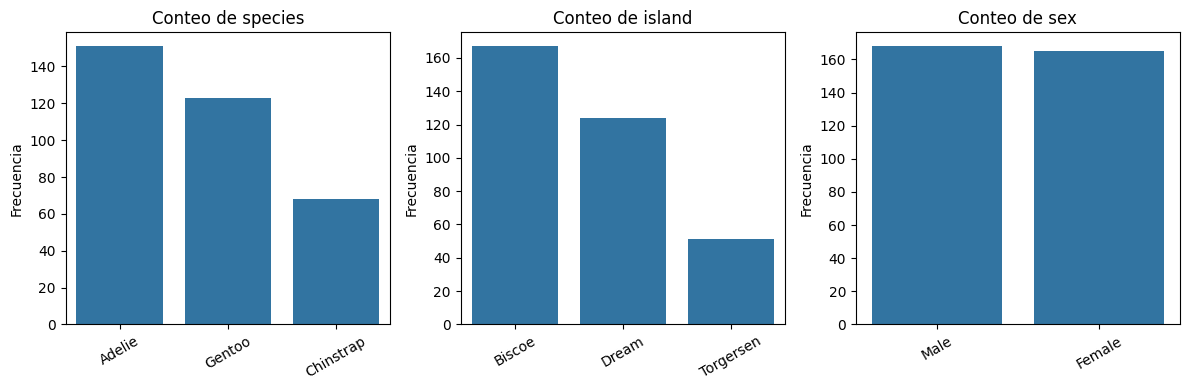

In [40]:
#countplots for low cardinality categorical columns
low_card_cols = ["species", "island", "sex"]  # ajusta si cambiaste el umbral

fig, axes = plt.subplots(1, len(low_card_cols), figsize=(4 * len(low_card_cols), 4))

for ax, col in zip(axes, low_card_cols):
    sns.countplot(data=penguins_clean, x=col, ax=ax, order=penguins_clean[col].value_counts().index)
    ax.set_title(f"Conteo de {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

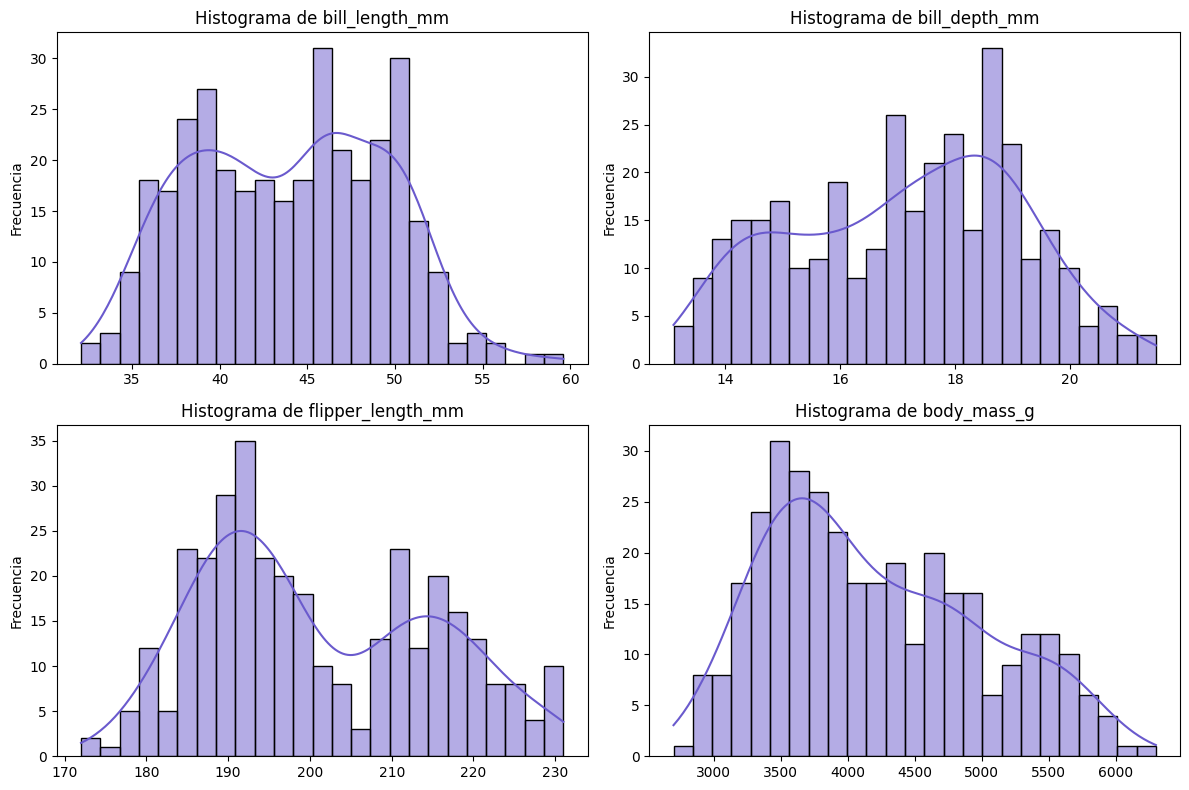

In [41]:
#histograms for numeric columns
penguins = pd.read_csv("penguins.csv")
numeric_cols = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=penguins, x=col, kde=True, ax=ax, bins=25, color="slateblue")
    ax.set_title(f"Histograma de {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()

Interpretación: en las distribuciones se puede evidenciar la frecuencia con la que aparecen datos repetidos con respecto a la infromación numérica proporcionada por los datos físicos de los pingüinos objervados. Es evidente que no siguen distribuciones normales, ya que no siguen la curva de campana, a priori podria decirse que la característica bimodal de las curvas se debe a que los datos no provienen de un grupo uniforma de pingüinos, es decir, de la información sumisnistrada es bien sabido que hay tres especies de pingüinos.

De forma individial, la gráfica de la longitud de pico (1) muestra que hay dos grupos: picos largos y cortos, además hay pocos pingüinos con picos muy largos (aprox. más de 55mm). De la gráfica de profundidad de pico (2) vemos que existen también dos grupos: delgados y ptros entre los 18-19 mm. La gráfica de longitud de aleta (3), también muestra que hay dos grupos, uno más dominante que otro ya que la separación de los picos de la figura es evidente. En cuanto a la última, el histograma de masa (4) se puede decir que existe una cola, se puede pensar que hay un grupo de pingüinos significativamente más grande que otra especie.

Lo más adecuado para interpretar los datos de manera correcta sería hacerlo por especie, por ejemplo:  si queremos información estadística tal como promedio de tamaño de aleta lo correcto no sería calcular el valor con todos los valores de la población, sino tomar la muestra perteneciente a cierta especie.

/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_1183/325368952.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x=cat_col, y=num_col, ax=ax, palette="Set3")
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_1183/325368952.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x=cat_col, y=num_col, ax=ax, palette="Set3")
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_1183/325368952.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x=cat_col, y=

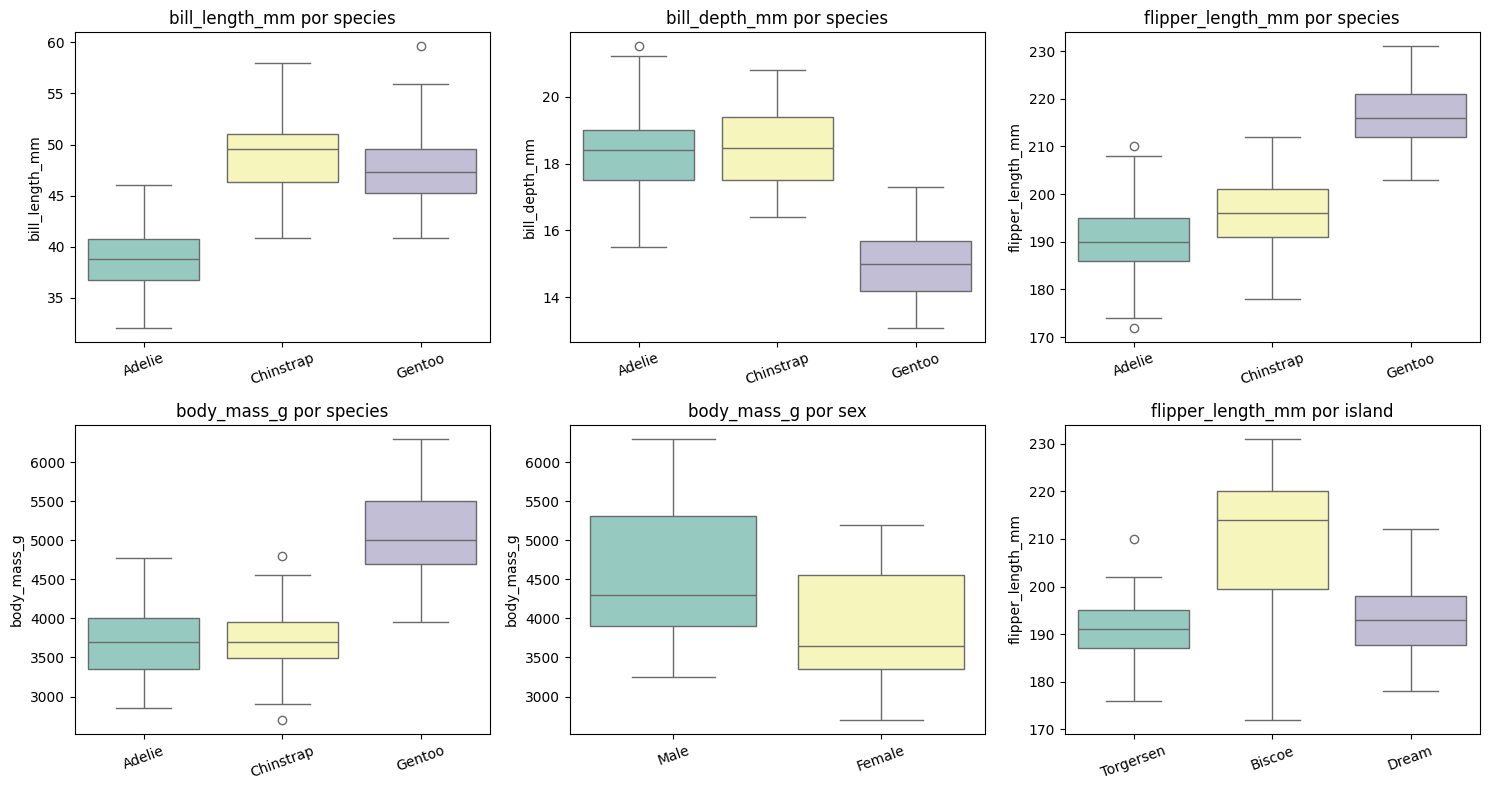

In [42]:
#boxplots for numeric columns by categorical columns
pairs = [
    ("bill_length_mm", "species"),
    ("bill_depth_mm", "species"),
    ("flipper_length_mm", "species"),
    ("body_mass_g", "species"),
    ("body_mass_g", "sex"),
    ("flipper_length_mm", "island"),
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()

for ax, (num_col, cat_col) in zip(axes, pairs):
    sns.boxplot(data=penguins_clean, x=cat_col, y=num_col, ax=ax, palette="Set3")
    ax.set_title(f"{num_col} por {cat_col}")
    ax.set_xlabel("")
    ax.set_ylabel(num_col)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

El análisis mediante diagramas de caja revela que la población de pingüinos presenta diferencias, tanto a nivel de especie como de sexo. La especie Gentoo se distingue claramente por ser la de mayor tamaño, peso y longitud de aletas, aunque posee picos más delgados en comparación con las especies Adelie y Chinstrap. Asimismo, se observa que los machos tienden a ser más robustos que las hembras de forma generalizada. Estas diferencias explican la bimodalidad observada en los histogramas iniciales, confirmando que las medidas físicas son variables predictoras clave para identificar la especie de cada individuo.

Los puntos aislados en los extremos de los diagramas representan valores atípicos. Estos indican la presencia de individuos con características físicas que se alejan significativamente del promedio de su especie o sexo, puede ser una variabilidad biológica natural dentro de la población estudiada como también pueden ser valores mal reportados.

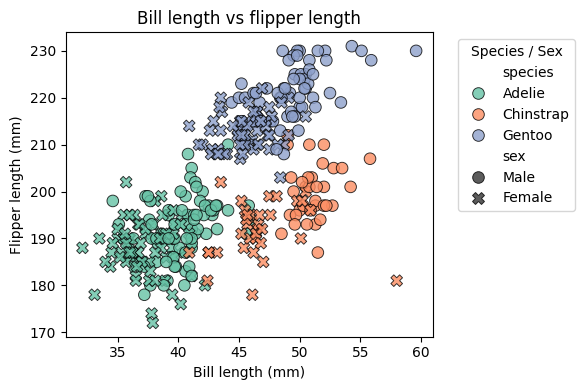

In [43]:
# Scatter plot for two numeric variables colored by category
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=penguins_clean,
    x="bill_length_mm",
    y="flipper_length_mm",
    hue="species",
    style="sex",
    palette="Set2",
    s=70,
    edgecolor="black",
    alpha=0.8,
)
plt.title("Bill length vs flipper length")
plt.xlabel("Bill length (mm)")
plt.ylabel("Flipper length (mm)")
plt.legend(title="Species / Sex", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

El diagrama de dispersión confirma que la longitud del pico y de las aletas son variables críticas para la clasificación de especies. Se observan tres agrupamientos definidos: los Adelie (pequeños en ambas dimensiones), los Gentoo (caracterizados por sus aletas largas) y los Chinstrap (que combinan picos largos con aletas cortas). Además, el uso de diferentes marcadores permite visualizar el dimorfismo sexual, donde los machos presentan dimensiones mayores que las hembras (por poco). Este gráfico demuestra que, combinando solo estas dos medidas, es posible identificar la especie de un pingüino con un alto grado de precisión.

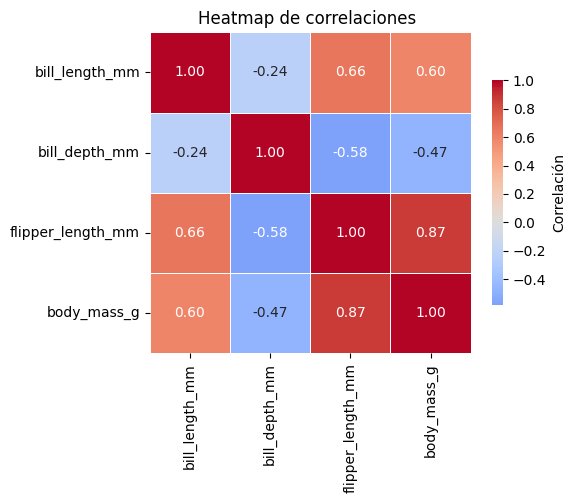

In [44]:
# Heatmap for correlation matrix
numeric = penguins_clean.select_dtypes(include="number")
corr_matrix = numeric.corr(method="pearson")

plt.figure(figsize=(6, 5))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.7, "label": "Correlación"},
)
plt.title("Heatmap de correlaciones ")
plt.tight_layout()
plt.show()

Este tipo de gráfico nos dice con números qué tan fuerte es la relación entre dos medidas (donde 1.00 es una relación perfecta, 0 es ninguna relación y los números negativos indican que mientras una variable sube, la otra baja).

## PARTE D 


Proponer al menos 3 hipótesis falsables basadas en los gráficos y descriptivos.

-La longitud de la aleta de los pingüinos Gentoo es significativamente mayor que la de las especies Adelie y Chinstrap.

-El crecimiento en la longitud del pico está más estrechamente relacionado con el largo de las aletas que con la masa corporal total.

-A pesar de ser la especie más pesada, los pingüinos Gentoo sus aletas son significativamentemenor que los Adelie y Chinstrap.

## Parte E — Pruebas estadísticas
- Seleccione una prueba adecuada para cada hipótesis (Pearson/Spearman, ANOVA/Kruskal, chi-cuadrado).

- Reporte estadístico y p-valor.

- Indique si la evidencia apoya o no la hipótesis, sin afirmar causalidad.

In [45]:
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Cargar datos y eliminar filas con valores faltantes para pruebas limpias
df = sns.load_dataset("penguins").dropna()

print("--- RESULTADOS ESTADÍSTICOS ---")

# Hipótesis 1: Gentoo tiene aletas más largas que Adelie y Chinstrap
adelie = df[df["species"] == "Adelie"]["flipper_length_mm"]
chinstrap = df[df["species"] == "Chinstrap"]["flipper_length_mm"]
gentoo = df[df["species"] == "Gentoo"]["flipper_length_mm"]
f_stat, p_val_anova = stats.f_oneway(adelie, chinstrap, gentoo)
tukey = pairwise_tukeyhsd(endog=df["flipper_length_mm"], groups=df["species"], alpha=0.05)
print(f"\n1) ANOVA flipper_length_mm ~ species -> F={f_stat:.2f}, p={p_val_anova:.4e}")
print("Post-hoc Tukey:")
print(tukey)

# Hipótesis 2: bill_length correlaciona más con flipper_length que con body_mass
r_flipper, p_flipper = stats.pearsonr(df["bill_length_mm"], df["flipper_length_mm"])
r_mass, p_mass = stats.pearsonr(df["bill_length_mm"], df["body_mass_g"])
print(f"\n2) Pearson bill_length vs flipper_length -> r={r_flipper:.2f}, p={p_flipper:.4e}")
print(f"   Pearson bill_length vs body_mass -> r={r_mass:.2f}, p={p_mass:.4e}")

# Hipótesis 3: Gentoo es más pesado pero con aletas más pequeñas que Adelie/Chinstrap
gentoo_mass = df[df["species"] == "Gentoo"]["body_mass_g"]
otras_mass = df[df["species"] != "Gentoo"]["body_mass_g"]
t_mass, p_mass_t = stats.ttest_ind(gentoo_mass, otras_mass, equal_var=False)
gentoo_flipper = df[df["species"] == "Gentoo"]["flipper_length_mm"]
otras_flipper = df[df["species"] != "Gentoo"]["flipper_length_mm"]
t_flipper, p_flipper_t = stats.ttest_ind(gentoo_flipper, otras_flipper, alternative="less", equal_var=False)
print(f"\n3a) t-test body_mass Gentoo vs otras -> t={t_mass:.2f}, p={p_mass_t:.4e}")
print(f"3b) t-test flipper_length Gentoo < otras -> t={t_flipper:.2f}, p={p_flipper_t:.4e}")

--- RESULTADOS ESTADÍSTICOS ---

1) ANOVA flipper_length_mm ~ species -> F=567.41, p=1.5874e-107
Post-hoc Tukey:
   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
  group1    group2  meandiff p-adj  lower   upper  reject
---------------------------------------------------------
   Adelie Chinstrap   5.7208   0.0  3.4144  8.0272   True
   Adelie    Gentoo  27.1326   0.0 25.1924 29.0727   True
Chinstrap    Gentoo  21.4118   0.0 19.0236 23.7999   True
---------------------------------------------------------

2) Pearson bill_length vs flipper_length -> r=0.65, p=7.2113e-42
   Pearson bill_length vs body_mass -> r=0.59, p=1.5386e-32

3a) t-test body_mass Gentoo vs otras -> t=25.15, p=3.3227e-66
3b) t-test flipper_length Gentoo < otras -> t=32.47, p=1.0000e+00


# Interpretación de las pruebas 
- **Hipótesis 1 (ANOVA):** `flipper_length_mm` difiere significativamente entre especies (F=567.41, p≈1.6×10⁻¹⁰⁷). Las comparaciones Tukey confirman que Gentoo tiene aletas más largas que Adelie y Chinstrap, por lo que la evidencia **apoya** la hipótesis.

- **Hipótesis 2 (Pearson):** La correlación entre `bill_length_mm` y `flipper_length_mm` es r=0.65 (p≈7.2×10⁻⁴²), mayor que la de `bill_length_mm` con `body_mass_g` (r=0.59, p≈1.5×10⁻³²). Ambas son fuertes, pero la relación con la aleta es más alta, por lo que la evidencia **apoya** la hipótesis.

- **Hipótesis 3 (t-tests):** Gentoo es más pesado que las otras especies (t=25.15, p≈3.3×10⁻⁶⁶), pero la prueba unilateral para “aletas menores” arroja p=1.0, es decir, Gentoo no tiene aletas más pequeñas; de hecho, son mayores. La evidencia **no apoya** esta hipótesis.

## Parte F — Conclusiones en tres capas
**A) Hallazgos descriptivos:**
- Gentoo presenta las mayores longitudes de aleta (media ≈ 217 mm) y masa corporal (>5.0 kg) frente a Adelie y Chinstrap, respaldado por las estadísticas descriptivas y el ANOVA con p≈1.6×10⁻¹⁰⁷.
- `bill_length_mm` se correlaciona fuertemente con `flipper_length_mm` (r≈0.65) y en menor medida con `body_mass_g` (r≈0.59), lo que sugiere una asociación estructural entre pico y aletas.
- Los conteos categóricos muestran que las tres especies están razonablemente balanceadas en la muestra, aunque `sex` tiene valores faltantes que deben considerarse en análisis posteriores.

**B) Patrones visuales:**
- Los histogramas de variables numéricas exhiben multimodalidad; la bimodalidad en `bill_length_mm` y `flipper_length_mm` coincide con las diferencias de especie observadas en los boxplots.
- Los boxplots y el scatter `bill_length_mm` vs `flipper_length_mm` muestran una clara separación entre especies, confirmando que las medidas físicas son discriminantes visuales efectivos.
- El heatmap resalta correlaciones altas entre tamaño de aleta y masa corporal, apoyando el patrón de que pingüinos más pesados tienden a tener aletas más largas.

**C) Próximas hipótesis a probar:**
1. Explorar si el dimorfismo sexual (machos vs hembras) explica una parte significativa de la varianza en `body_mass_g` dentro de cada especie (ANOVA de dos factores).
2. Evaluar si la isla de procedencia (`island`) influye en la masa corporal o longitud de aleta tras controlar por especie (modelo lineal o ANOVA estratificado).
3. Investigar si los valores atípicos detectados en los boxplots corresponden a errores de medición o representan subpoblaciones (p. ej., juveniles) mediante análisis de outliers y metadatos adicionales.

## Reporte HTML consolidado

Ejecuta la siguiente celda para generar un resumen en HTML con la descripción, visualizaciones y pruebas estadísticas.

In [11]:
import io
import base64
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from IPython.display import HTML

# --- Carga de datos ---
penguins_clean = sns.load_dataset("penguins").dropna()

# --- 1. Descripción estadística ---
numeric_desc = penguins_clean.select_dtypes(include="number")
numeric_stats = pd.DataFrame({
    "media": numeric_desc.mean(),
    "mediana": numeric_desc.median(),
    "desviacion_std": numeric_desc.std(ddof=1),
    "rango_intercuartil": numeric_desc.quantile(0.75) - numeric_desc.quantile(0.25),
}).round(2)

categorical_desc = {}
for col in penguins_clean.select_dtypes(exclude="number").columns:
    counts = penguins_clean[col].value_counts(dropna=False)
    categorical_desc[col] = pd.DataFrame({
        "conteos": counts,
        "porcentaje": (counts / len(penguins_clean) * 100).round(2)
    })

ctables = {
    "species × island": pd.crosstab(penguins_clean["species"], penguins_clean["island"], margins=True),
    "species × sex": pd.crosstab(penguins_clean["species"], penguins_clean["sex"], margins=True),
    "island × sex": pd.crosstab(penguins_clean["island"], penguins_clean["sex"], margins=True),
}

corr_matrix = numeric_desc.corr(method="pearson").round(2)

# --- 2. Visualizaciones ---
def fig_to_base64(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", bbox_inches="tight", dpi=150)
    plt.close(fig)
    buf.seek(0)
    return base64.b64encode(buf.read()).decode("utf-8")

visuals = []

# 2.1 Conteos categóricos
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, col in zip(axes, ["species", "island", "sex"]):
    sns.countplot(data=penguins_clean, x=col, ax=ax, order=penguins_clean[col].value_counts().index)
    ax.set_title(f"Conteo de {col}")
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=30)
visuals.append(("Conteos de variables categóricas", fig_to_base64(fig), None))

# 2.2 Distribuciones numéricas
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, col in zip(axes.ravel(), ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]):
    sns.histplot(data=penguins_clean, x=col, kde=True, ax=ax, bins=25, color="slateblue")
    ax.set_title(f"Histograma de {col}")
    ax.set_xlabel("")
int_dist = """
<strong>Interpretación:</strong> En las distribuciones se puede evidenciar la frecuencia con la que aparecen datos repetidos. Es evidente que no siguen distribuciones normales (bimodalidad por especies). 
<ul>
    <li><strong>Pico (1 y 2):</strong> Existen dos grupos claros de longitud y profundidad.</li>
    <li><strong>Aletas (3):</strong> Separación evidente entre grupos.</li>
    <li><strong>Masa (4):</strong> Existe una cola que sugiere una especie significativamente más grande.</li>
</ul>
"""
visuals.append(("Distribuciones numéricas", fig_to_base64(fig), int_dist))

# 2.3 Boxplots
pairs = [("bill_length_mm", "species"), ("bill_depth_mm", "species"), ("flipper_length_mm", "species"), ("body_mass_g", "species"), ("body_mass_g", "sex"), ("flipper_length_mm", "island")]
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, (num_col, cat_col) in zip(axes.ravel(), pairs):
    sns.boxplot(data=penguins_clean, x=cat_col, y=num_col, ax=ax, palette="Set3")
    ax.set_title(f"{num_col} por {cat_col}")
    ax.tick_params(axis="x", rotation=20)
int_box = """
<strong>Interpretación:</strong> Gentoo destaca por mayor tamaño y peso, pero picos más delgados. Los machos son generalmente más robustos. Los puntos aislados son valores atípicos que podrían ser variabilidad natural o errores de reporte.
"""
visuals.append(("Comparaciones numéricas vs categóricas", fig_to_base64(fig), int_box))

# 2.4 Scatterplot
fig, ax = plt.subplots(figsize=(6, 4))
sns.scatterplot(data=penguins_clean, x="bill_length_mm", y="flipper_length_mm", hue="species", style="sex", palette="Set2", s=70, edgecolor="black", alpha=0.8, ax=ax)
ax.set_title("Bill length vs flipper length")
ax.legend(title="Species / Sex", bbox_to_anchor=(1.02, 1), loc="upper left")
int_scatter = """
<strong>Interpretación:</strong> Se observan tres agrupamientos definidos por especie. El gráfico demuestra que combinando estas dos medidas es posible identificar la especie con alta precisión.
"""
visuals.append(("Dispersión bill vs flipper", fig_to_base64(fig), int_scatter))

# 2.5 Heatmap
fig, ax = plt.subplots(figsize=(5.5, 5))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True, linewidths=0.5, ax=ax)
int_heat = "<strong>Interpretación:</strong> Muestra la fuerza de relación entre variables (1.00 perfecta, 0 ninguna, negativos inversa)."
visuals.append(("Correlaciones", fig_to_base64(fig), int_heat))

# --- 3. Pruebas estadísticas ---
adelie = penguins_clean[penguins_clean["species"] == "Adelie"]["flipper_length_mm"]
chinstrap = penguins_clean[penguins_clean["species"] == "Chinstrap"]["flipper_length_mm"]
gentoo = penguins_clean[penguins_clean["species"] == "Gentoo"]["flipper_length_mm"]
f_stat, p_val_anova = stats.f_oneway(adelie, chinstrap, gentoo)
tukey = pairwise_tukeyhsd(endog=penguins_clean["flipper_length_mm"], groups=penguins_clean["species"], alpha=0.05)
r_flipper, p_flipper = stats.pearsonr(penguins_clean["bill_length_mm"], penguins_clean["flipper_length_mm"])
gentoo_mass = penguins_clean[penguins_clean["species"] == "Gentoo"]["body_mass_g"]
otras_mass = penguins_clean[penguins_clean["species"] != "Gentoo"]["body_mass_g"]
t_mass, p_mass_t = stats.ttest_ind(gentoo_mass, otras_mass, equal_var=False)

stat_cards = [
    {"titulo": "H1: Gentoo tiene aletas más largas", "prueba": "ANOVA", "estadistico": f"F = {f_stat:.2f}", "pvalor": f"p = {p_val_anova:.2e}", "decision": "Evidencia a favor."},
    {"titulo": "H2: Relación pico-aleta", "prueba": "Pearson", "estadistico": f"r = {r_flipper:.2f}", "pvalor": f"p = {p_flipper:.2e}", "decision": "Correlación significativa."},
    {"titulo": "H3: Peso Gentoo vs Otras", "prueba": "t-test Welch", "estadistico": f"t = {t_mass:.2f}", "pvalor": f"p = {p_mass_t:.2e}", "decision": "Gentoo es más pesado."}
]

# --- 4. Construcción del HTML ---

styles = """
<style>
@import url('https://fonts.googleapis.com/css2?family=Poppins:wght@400;500;600&display=swap');
:root { --bg: #f6f7fb; --card-bg: #ffffff; --primary: #4338ca; --text: #1f2933; }
* { box-sizing: border-box; }
body { font-family: 'Poppins', sans-serif; background: var(--bg); color: var(--text); margin: 0; }
main { max-width: 1200px; margin: 0 auto; padding: 32px 20px; }
header.hero { background: linear-gradient(120deg, #4f46e5, #6366f1); color: #fff; padding: 40px 20px; text-align: center; }
.card { background: var(--card-bg); border-radius: 18px; padding: 24px; margin-bottom: 28px; box-shadow: 0 10px 25px rgba(0,0,0,0.05); overflow: hidden; }
h2 { color: var(--primary); border-bottom: 2px solid #f0f0f0; padding-bottom: 10px; margin-top: 0; }
h3 { margin: 25px 0 10px; font-size: 1.2rem; color: var(--primary); }
.table-container { width: 100%; overflow-x: auto; margin-bottom: 20px; border: 1px solid #eee; border-radius: 8px; }
.table { border-collapse: collapse; width: 100%; min-width: 400px; font-size: 0.9rem; }
.table th, .table td { border: 1px solid #f0f0f0; padding: 10px; text-align: center; }
.table th { background: #f9fafb; }
.grid-2 { display: grid; gap: 30px; grid-template-columns: repeat(auto-fit, minmax(450px, 1fr)); }
.media-card { background: #fff; border: 1px solid #f0f0f0; padding: 15px; border-radius: 15px; }
.media-card img { width: 100%; height: auto; border-radius: 10px; margin-bottom: 15px; }
.interpretation { background: #f8fafc; padding: 15px; border-radius: 10px; border-left: 4px solid var(--primary); font-size: 0.9rem; line-height: 1.6; }
.conclusion-layer { margin-bottom: 20px; }
.conclusion-layer ul { padding-left: 20px; margin: 5px 0; }
.conclusion-layer li { margin-bottom: 8px; font-size: 0.95rem; }
.stat-card { background: #f8f5ff; border-radius: 14px; padding: 16px; border: 1px solid rgba(79,70,229,0.15); }
</style>
"""

# Secciones previas
desc_section = ["<section class='card'>", "<h2>Descripción estadística</h2>", "<div class='grid-2'>", "<div><h3>Variables numéricas</h3><div class='table-container'>", numeric_stats.to_html(classes="table", border=0), "</div></div>", "<div><h3>Variables categóricas</h3><div class='grid-2' style='gap:10px;'>"]
for col, table in categorical_desc.items(): desc_section.append(f"<div><h4>{col}</h4><div class='table-container'>{table.to_html(classes='table', border=0)}</div></div>")
desc_section.append("</div></div></div><h3 style='margin-top:30px'>Análisis de contingencia</h3><div class='grid-2'>")
for title, table in ctables.items(): desc_section.append(f"<div><h4>{title}</h4><div class='table-container'>{table.to_html(classes='table', border=0)}</div></div>")
desc_section.append("</div><h3>Matriz de correlación</h3><div class='table-container'>" + corr_matrix.to_html(classes="table", border=0) + "</div></section>")

visual_section = ["<section class='card'>", "<h2>Visualizaciones</h2>", "<div class='grid-2'>"]
for title, img_b64, interpretation in visuals:
    visual_section.append(f"<div class='media-card'><h3>{title}</h3><img src='data:image/png;base64,{img_b64}'>")
    if interpretation: visual_section.append(f"<div class='interpretation'>{interpretation}</div>")
    visual_section.append("</div>")
visual_section.append("</div></section>")

stats_section = ["<section class='card'>", "<h2>Pruebas estadísticas</h2>", "<div class='grid-2'>"]
for card in stat_cards: stats_section.append(f"<article class='stat-card'><h3>{card['titulo']}</h3><p><strong>Prueba:</strong> {card['prueba']}<br><strong>Estadístico:</strong> {card['estadistico']}<br><strong>p-valor:</strong> {card['pvalor']}<br><strong>Conclusión:</strong> {card['decision']}</p></article>")
stats_section.append("</div></section>")

# --- Nueva Sección: Conclusiones ---
conclusions_section = [
    "<section class='card'>",
    "<h2>Conclusiones finales</h2>",
    
    "<div class='conclusion-layer'>",
    "<h3>A) Hallazgos descriptivos:</h3>",
    "<ul>",
    "<li>Gentoo presenta las mayores longitudes de aleta (media ≈ 217 mm) y masa corporal (>5.0 kg) frente a Adelie y Chinstrap, respaldado por las estadísticas descriptivas y el ANOVA con p≈1.6×10⁻¹⁰⁷.</li>",
    "<li><code>bill_length_mm</code> se correlaciona fuertemente con <code>flipper_length_mm</code> (r≈0.65) y en menor medida con <code>body_mass_g</code> (r≈0.59), lo que sugiere una asociación estructural entre pico y aletas.</li>",
    "<li>Los conteos categóricos muestran que las tres especies están razonablemente balanceadas en la muestra, aunque <code>sex</code> tiene valores faltantes que deben considerarse en análisis posteriores.</li>",
    "</ul>",
    "</div>",

    "<div class='conclusion-layer'>",
    "<h3>B) Patrones visuales:</h3>",
    "<ul>",
    "<li>Los histogramas de variables numéricas exhiben multimodalidad; la bimodalidad en <code>bill_length_mm</code> y <code>flipper_length_mm</code> coincide con las diferencias de especie observadas en los boxplots.</li>",
    "<li>Los boxplots y el scatter <code>bill_length_mm</code> vs <code>flipper_length_mm</code> muestran una clara separación entre especies, confirmando que las medidas físicas son discriminantes visuales efectivos.</li>",
    "<li>El heatmap resalta correlaciones altas entre tamaño de aleta y masa corporal, apoyando el patrón de que pingüinos más pesados tienden a tener aletas más largas.</li>",
    "</ul>",
    "</div>",

    "<div class='conclusion-layer'>",
    "<h3>C) Próximas hipótesis a probar:</h3>",
    "<ol>",
    "<li>Explorar si el dimorfismo sexual (machos vs hembras) explica una parte significativa de la varianza en <code>body_mass_g</code> dentro de cada especie (ANOVA de dos factores).</li>",
    "<li>Evaluar si la isla de procedencia (<code>island</code>) influye en la masa corporal o longitud de aleta tras controlar por especie (modelo lineal o ANOVA estratificado).</li>",
    "<li>Investigar si los valores atípicos detectados en los boxplots corresponden a errores de medición o representan subpoblaciones (p. ej., juveniles) mediante análisis de outliers y metadatos adicionales.</li>",
    "</ol>",
    "</div>",
    "</section>"
]

header = "<header class='hero'><p>Laboratorio 1 · Observatorio de datos</p><h1>Pingüinos de Seaborn</h1></header>"
report_html = f"<!DOCTYPE html><html lang='es'><head><meta charset='UTF-8'>{styles}</head><body>{header}<main>{''.join(desc_section + visual_section + stats_section + conclusions_section)}</main></body></html>"

with open('reporte.html', 'w', encoding='utf-8') as f: f.write(report_html)
print("Reporte final guardado como reporte.html")


/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_3022/4174678890.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x=cat_col, y=num_col, ax=ax, palette="Set3")
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_3022/4174678890.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x=cat_col, y=num_col, ax=ax, palette="Set3")
/var/folders/wt/yys095ds4397thwy34m1321h0000gn/T/ipykernel_3022/4174678890.py:78: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=penguins_clean, x=cat_col,

Reporte final guardado como reporte.html
